# 02. EDA and Data Split

### AAI-590 Group 9: Tyler Clinscales, Edwin Merchan, Geoffrey Fadera
---

The EDA and data split on this notebook are geared towards the production simulation part of our project.<br>
Here, we split the data in both location and time - we continuously improve our model on the same locations as new data become available in the future, and also want to monitor and evaluate its usability on other camera locations (completely unseen) but from the same "US Southwestern Region" - CCT20 Study<br>

The CCT20 study already provides a locations-based split, 100 locations for 'train' and 40 location as 'val'.

        (1) 'in-location' dataset: we will use the cct20 'train' dataset as our in-distrubution dataset. All modeling, evaluation, future ml pipeline system improvements are all based on data fron this dataset!

        (2) 'out-location' dataset: evaluate transferability to unknown locations within the same region
 

Finally, we split both datasets between 1st year data, and remaining years data.

        (1) 1st year dataset: 
            *  in-location : used for baseline modeling. we used the train-val-test split provided in the CCT Benchmark study to avoid potential leakage when simple class stratification is used
            *  out-location : used as out-of-distribution test set, evaluate transferability

        (2) remaining years dataset:
            * in-location : production fine-tuning, reliability, active labeling of uncertain samples
            * out-location : transferability checks


With this in mind, we perform the following EDA to understand distribution trends over time on in-location data, and similarity in distribution trends between in-location and out-location data. 



---

In [81]:
import subprocess
import sys
import os
import json
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd

# Specify the path to the folder containing your module
repo_root_rel = '../'

src_path = os.path.join(repo_root_rel, '')
# Add src_path to sys.path if not already present
if repo_root_rel not in sys.path:
        sys.path.insert(0,repo_root_rel)
        sys.path.append(src_path)


import src.eda.eda_utils as eda
import importlib # for debug

In [2]:
# Step 1. Load master metadata of preprocessed images from 01_eda_&_preprocessing.ipynb

grp_meta_df =[]
grp_meta_df = pd.read_csv(f'../dataset/grp4_metadata_with_datetime.csv')
grp_meta_df['date_captured'] = pd.to_datetime(grp_meta_df['date_captured'], errors='coerce')

# Step 2. Add Time Feature Columns ( Year-Month, Minute-Of-Day, Day-of-Year, Cyclical Encodings of MinuteOfDay and DayOfYear) 
grp_meta_df['year_month'] = grp_meta_df['date_captured'].dt.to_period('M')

# Extract minute of day from 'date_captured' column
grp_meta_df['minute_of_day'] = grp_meta_df['date_captured'].dt.hour * 60 + grp_meta_df['date_captured'].dt.minute

# Extract day of year
grp_meta_df['day_of_year'] = grp_meta_df['date_captured'].dt.dayofyear

# Apply cyclical encoding of minute of day to expose nocturnal habits
grp_meta_df['minOfDay_sin'] = np.sin(2 * np.pi * grp_meta_df['minute_of_day'] / 1440)	
grp_meta_df['minOfDay_cos'] = np.cos(2 * np.pi * grp_meta_df['minute_of_day'] / 1440)

# Apply cyclical encoding of day of year to expose seasonal changes in animal habits
grp_meta_df['dayOfYear_sin'] = np.sin(2 * np.pi * grp_meta_df['day_of_year'] / 365)
grp_meta_df['dayOfYear_cos'] = np.cos(2 * np.pi * grp_meta_df['day_of_year'] / 365)

# check df
grp_meta_df.head()

,filename,label,category_id,bbox,image_id,location,split_type,date_captured,year_month,minute_of_day,day_of_year,minOfDay_sin,minOfDay_cos,dayOfYear_sin,dayOfYear_cos
0,585f4d43-23d2-11e8-a6a3-ec086b02610b_0.jpg,cat,16,"[1200.64, 568.32, 146.7734375, 246.613359375]",585f4d43-23d2-11e8-a6a3-ec086b02610b,100,val,2010-05-25 20:32:56,2010-05,1232.0,145.0,-0.788011,0.615661,0.601624,-0.798779
1,59180801-23d2-11e8-a6a3-ec086b02610b_0.jpg,cat,16,"[999.253359375, 404.48, 129.706640625, 218.453...",59180801-23d2-11e8-a6a3-ec086b02610b,100,val,2010-05-25 20:32:57,2010-05,1232.0,145.0,-0.788011,0.615661,0.601624,-0.798779
2,588dba7d-23d2-11e8-a6a3-ec086b02610b_0.jpg,opossum,1,"[1213.44, 637.44, 212.48, 271.36]",588dba7d-23d2-11e8-a6a3-ec086b02610b,100,val,2010-05-25 22:35:28,2010-05,1355.0,145.0,-0.362438,0.932008,0.601624,-0.798779
3,58bea7d7-23d2-11e8-a6a3-ec086b02610b_0.jpg,opossum,1,"[1062.4, 808.96, 279.04, 238.08]",58bea7d7-23d2-11e8-a6a3-ec086b02610b,100,val,2010-05-25 22:35:29,2010-05,1355.0,145.0,-0.362438,0.932008,0.601624,-0.798779
4,58a8a344-23d2-11e8-a6a3-ec086b02610b_0.jpg,opossum,1,"[870.4, 960.0, 261.12, 337.92]",58a8a344-23d2-11e8-a6a3-ec086b02610b,100,val,2010-05-25 22:35:30,2010-05,1355.0,145.0,-0.362438,0.932008,0.601624,-0.798779


In [3]:
# Step 3. Location-based split. (see 02_eda_spatial_temporal_split.ipynb)
df = grp_meta_df.copy()
df = df.reset_index(drop=True)

# Create splits
known_locs_df = df[df['split_type'] == 'train']
new_locs_df = df[df['split_type'] == 'val']

In [4]:
# Step 4.show known and new locs df value counts in one table
known_new_counts = pd.concat([known_locs_df['label'].value_counts(), new_locs_df['label'].value_counts()], axis=1).fillna(0).astype(int)
known_new_counts.columns = ['Known Locs', 'New Locs']
known_new_counts.loc['Total'] = known_new_counts.sum(numeric_only=True)
display(known_new_counts)
known_new_counts = known_new_counts.drop('Total')

,Known Locs,New Locs
label,,
opossum,7162,4972
rabbit,5272,753
coyote,4212,2293
deer,3411,3017
raccoon,3076,4832
cat,2999,1392
bird,2735,1291
bobcat,2204,2844
squirrel,1852,796


In [5]:
# step 5 get value_counts of 'label' if year_month is between '2011-03' and '2012-02'
year_counts = []
yearly_counts = pd.DataFrame({
    'Train (Year1)': known_locs_df[known_locs_df['year_month'].between('2011-03', '2012-02')]['label'].value_counts(),
    'Val-OOD (Year1)': new_locs_df[new_locs_df['year_month'].between('2011-03', '2012-02')]['label'].value_counts(),

    'Train (Year2)': known_locs_df[known_locs_df['year_month'].between('2012-03', '2013-02')]['label'].value_counts(),
    'Val-OOD (Year2)': new_locs_df[new_locs_df['year_month'].between('2012-03', '2013-02')]['label'].value_counts(),

    'Train (Year3)': known_locs_df[known_locs_df['year_month'].between('2013-03', '2014-02')]['label'].value_counts(),
    'Val-OOD (Year3)': new_locs_df[new_locs_df['year_month'].between('2013-03', '2014-02')]['label'].value_counts(),

    'Train (Year4)': known_locs_df[known_locs_df['year_month'].between('2014-03', '2015-02')]['label'].value_counts(),
    'Val-OOD (Year4)': new_locs_df[new_locs_df['year_month'].between('2014-03', '2015-02')]['label'].value_counts()
})

#yearly_counts.loc['Total'] = known_new_counts.sum(numeric_only=True)
display(yearly_counts)

,Train (Year1),Val-OOD (Year1),Train (Year2),Val-OOD (Year2),Train (Year3),Val-OOD (Year3),Train (Year4),Val-OOD (Year4)
label,,,,,,,,
badger,3.0,10.0,7.0,1.0,NaN,NaN,NaN,3.0
bat,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
bird,611.0,82.0,434.0,50.0,697.0,98.0,900.0,990.0
bobcat,1423.0,1983.0,459.0,662.0,209.0,139.0,102.0,24.0
car,1224.0,747.0,234.0,226.0,33.0,93.0,NaN,NaN
cat,1798.0,395.0,1201.0,818.0,NaN,NaN,NaN,NaN
coyote,2051.0,1090.0,1177.0,785.0,386.0,99.0,512.0,237.0
deer,55.0,NaN,185.0,NaN,1134.0,1256.0,2019.0,630.0
dog,1222.0,234.0,545.0,247.0,73.0,48.0,10.0,NaN


In [6]:
# Check distributions if labels with less than 100 samples in known_locs_df are removed
known_new_counts = known_new_counts[known_new_counts['Known Locs'] >= 400]
known_new_counts

,Known Locs,New Locs
label,,
opossum,7162,4972
rabbit,5272,753
coyote,4212,2293
deer,3411,3017
raccoon,3076,4832
cat,2999,1392
bird,2735,1291
bobcat,2204,2844
squirrel,1852,796


In [8]:
# Filter the dataframes based on the labels that have at least 50 samples in both known and new locs
known_labels = known_new_counts.index.tolist()
known_locs_df = known_locs_df[known_locs_df['label'].isin(known_labels)]
new_locs_df = new_locs_df[new_locs_df['label'].isin(known_labels)]
# Reset index after filtering
known_locs_df = known_locs_df.reset_index(drop=True)
new_locs_df = new_locs_df.reset_index(drop=True)

In [11]:
distribution_df = pd.DataFrame({
    'in-location': known_locs_df['label'].value_counts(),
    'out-location': new_locs_df['label'].value_counts()
}).fillna(0).astype(int)
distribution_df['total'] = distribution_df.sum(axis=1)
# Reindex the distribution_df to ensure it contains all known labels
known_labels = known_new_counts.index.tolist()
distribution_df = distribution_df.reindex(known_labels)  # Ensure the order of labels is consistent
# add row 'total' with sum of each column
distribution_df.loc['total'] = distribution_df.sum(numeric_only=True)
display(distribution_df)
distribution_df.to_csv('./total_distribution_df.csv')

,in-location,out-location,total
label,,,
opossum,7162,4972,12134
rabbit,5272,753,6025
coyote,4212,2293,6505
deer,3411,3017,6428
raccoon,3076,4832,7908
cat,2999,1392,4391
bird,2735,1291,4026
bobcat,2204,2844,5048
squirrel,1852,796,2648


In [13]:
# get value_counts of 'label' if year_month is between '2011-03' and '2012-02'
year_counts = []
yearly_counts = pd.DataFrame({
    'in-loc (Year1)': known_locs_df[known_locs_df['year_month'].between('2011-03', '2012-02')]['label'].value_counts(),
    'out-loc (Year1)': new_locs_df[new_locs_df['year_month'].between('2011-03', '2012-02')]['label'].value_counts(),

    'in-loc (Year2)': known_locs_df[known_locs_df['year_month'].between('2012-03', '2013-02')]['label'].value_counts(),
    'out-loc (Year2)': new_locs_df[new_locs_df['year_month'].between('2012-03', '2013-02')]['label'].value_counts(),

    'in-loc (Year3)': known_locs_df[known_locs_df['year_month'].between('2013-03', '2014-02')]['label'].value_counts(),
    'out-loc (Year3)': new_locs_df[new_locs_df['year_month'].between('2013-03', '2014-02')]['label'].value_counts(),

    'in-loc (Year4)': known_locs_df[known_locs_df['year_month'].between('2014-03', '2015-02')]['label'].value_counts(),
    'out-loc (Year4)': new_locs_df[new_locs_df['year_month'].between('2014-03', '2015-02')]['label'].value_counts()
})


# Reindex the yearly_counts to ensure it contains all known labels
known_labels = known_new_counts.index.tolist()
yearly_counts = yearly_counts.reindex(known_labels)  # Ensure the order of labels is consistent
yearly_counts.loc['Total'] = yearly_counts.sum(numeric_only=True).astype(int)
display(yearly_counts)
yearly_counts.to_csv('./yearly_counts.csv')

,in-loc (Year1),out-loc (Year1),in-loc (Year2),out-loc (Year2),in-loc (Year3),out-loc (Year3),in-loc (Year4),out-loc (Year4)
label,,,,,,,,
opossum,4403,2438.0,2759,1823.0,NaN,NaN,NaN,NaN
rabbit,2768,478.0,580,162.0,420.0,39.0,758.0,15.0
coyote,2051,1090.0,1177,785.0,386.0,99.0,512.0,237.0
deer,55,NaN,185,NaN,1134.0,1256.0,2019.0,630.0
raccoon,2129,2647.0,758,480.0,168.0,23.0,21.0,NaN
cat,1798,395.0,1201,818.0,NaN,NaN,NaN,NaN
bird,611,82.0,434,50.0,697.0,98.0,900.0,990.0
bobcat,1423,1983.0,459,662.0,209.0,139.0,102.0,24.0
squirrel,1396,430.0,406,160.0,46.0,3.0,4.0,NaN


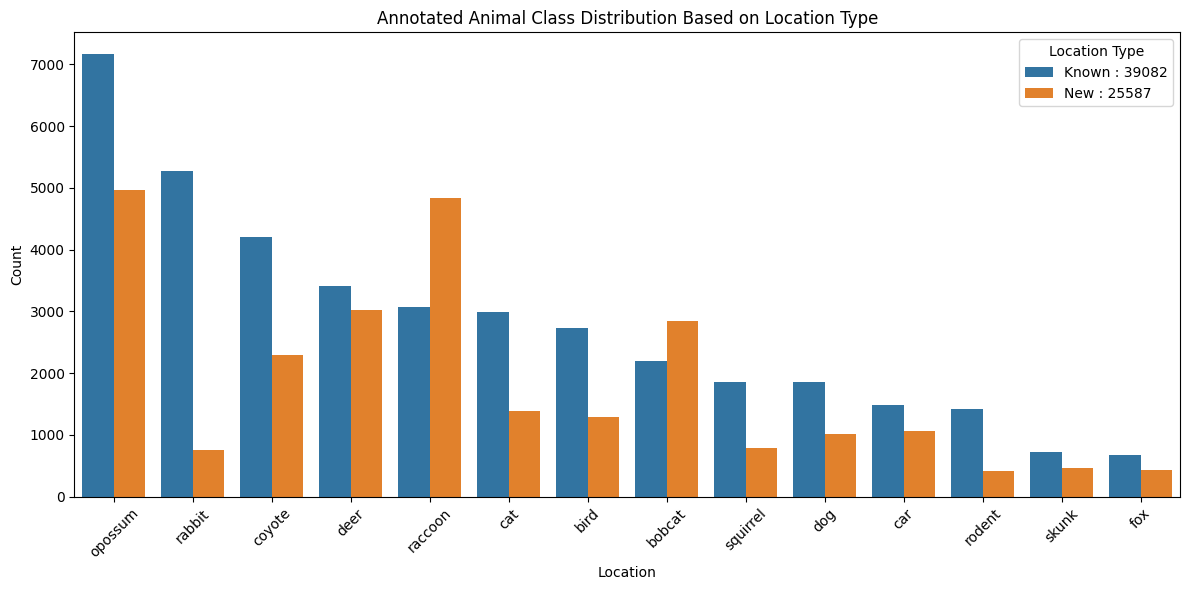

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

sns.set_palette("tab10")
ax = sns.barplot(data=known_new_counts.reset_index().melt(id_vars='label'), 
            x='label', y='value', hue='variable')
# Set the title and labels
plt.title('Annotated Animal Class Distribution Based on Location Type')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45)

# configure legend to add the total count per location

legend_labels = [f'Known : {known_new_counts['Known Locs'].sum()}',
                  f'New : {known_new_counts['New Locs'].sum()}'] 

handles, labels = ax.get_legend_handles_labels()

ax.legend(title='Location Type', loc='upper right', handles = handles, labels=legend_labels)
#plt.legend(title='Dataset Type', loc='upper right')

plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

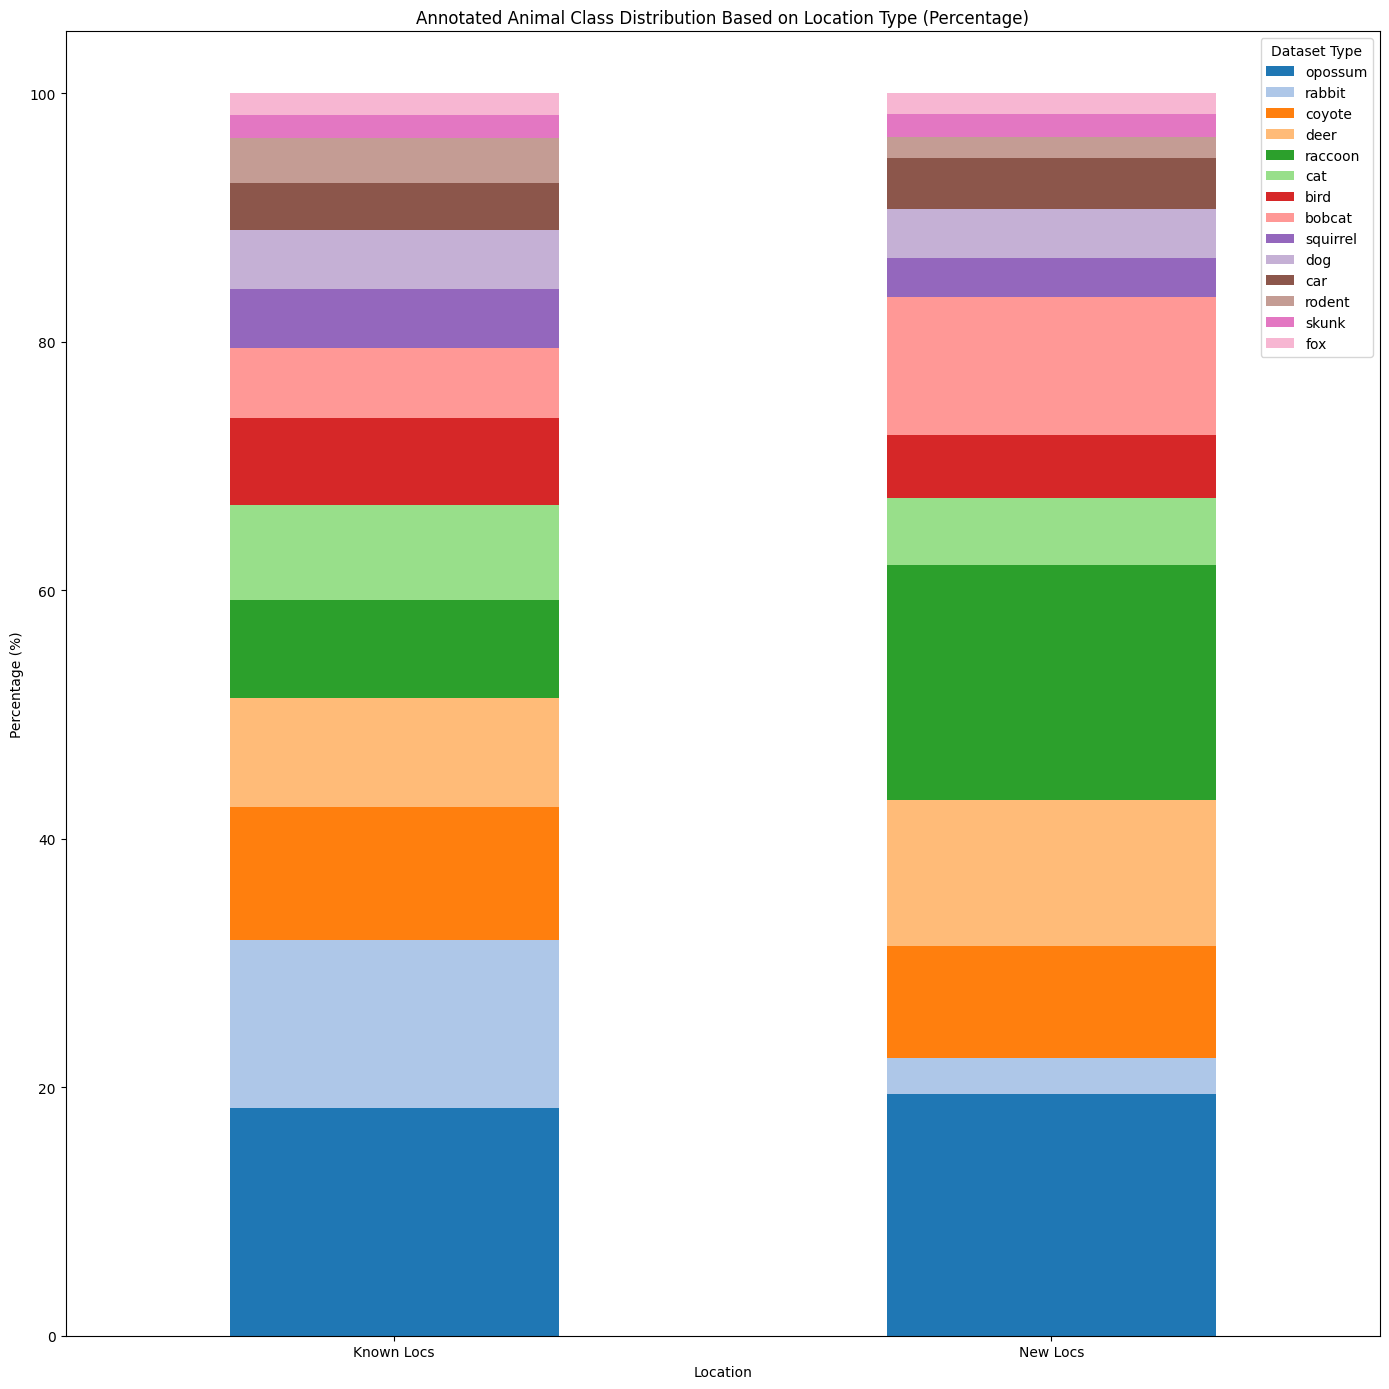

In [15]:
# now display the % distribution of the classes in known and new locations
tmp_df = known_new_counts.T.copy()
known_new_counts_percent = tmp_df.div(tmp_df.sum(axis=1), axis=0) * 100


plt.figure(figsize=(6, 6))
sns.set_palette("tab20", n_colors=len(known_new_counts))

ax = known_new_counts_percent.plot(kind='bar', stacked=True, figsize=(14, 14))

# Melt the DataFrame for easier plotting
#ax = sns.barplot(data=known_new_counts_percent.reset_index().melt(id_vars='index'), 
#            x='index', y='value', hue='variable')
# Set the title and labels
plt.title('Annotated Animal Class Distribution Based on Location Type (Percentage)')
plt.xlabel('Location')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.legend(title='Dataset Type', loc='upper right')

plt.tight_layout()
plt.show()



/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan/experiments5/../src/eda/eda_utils.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby(['year_month', feature_name]).size().unstack(fill_value=0)


<Figure size 1400x800 with 0 Axes>

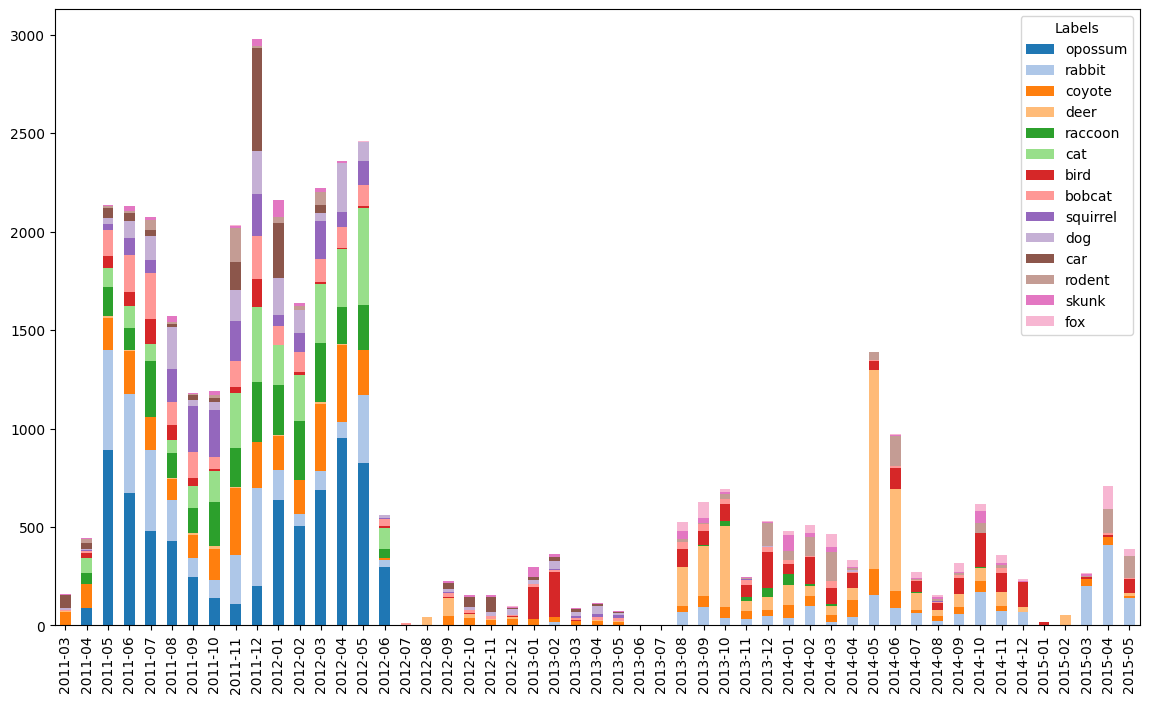

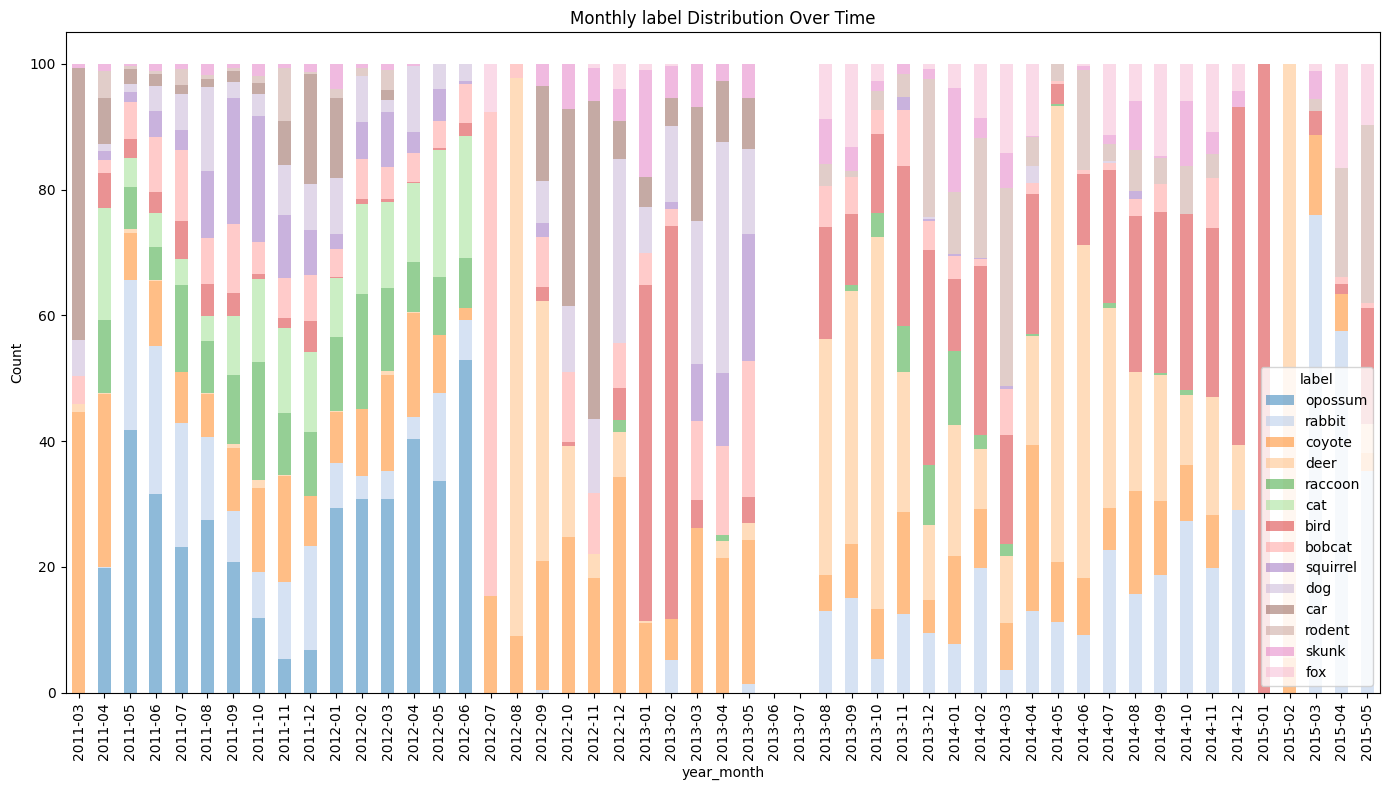

In [16]:
# plot monthly class distribution for known_locs_df
known_locs_df['label'] = pd.Categorical(known_locs_df['label'], categories=known_labels, ordered=True)
eda.plot_monthly_class_distribution(known_locs_df, feature_name = 'label', color_palette='tab20')

/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan/experiments5/../src/eda/eda_utils.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby(['year_month', feature_name]).size().unstack(fill_value=0)


<Figure size 1400x800 with 0 Axes>

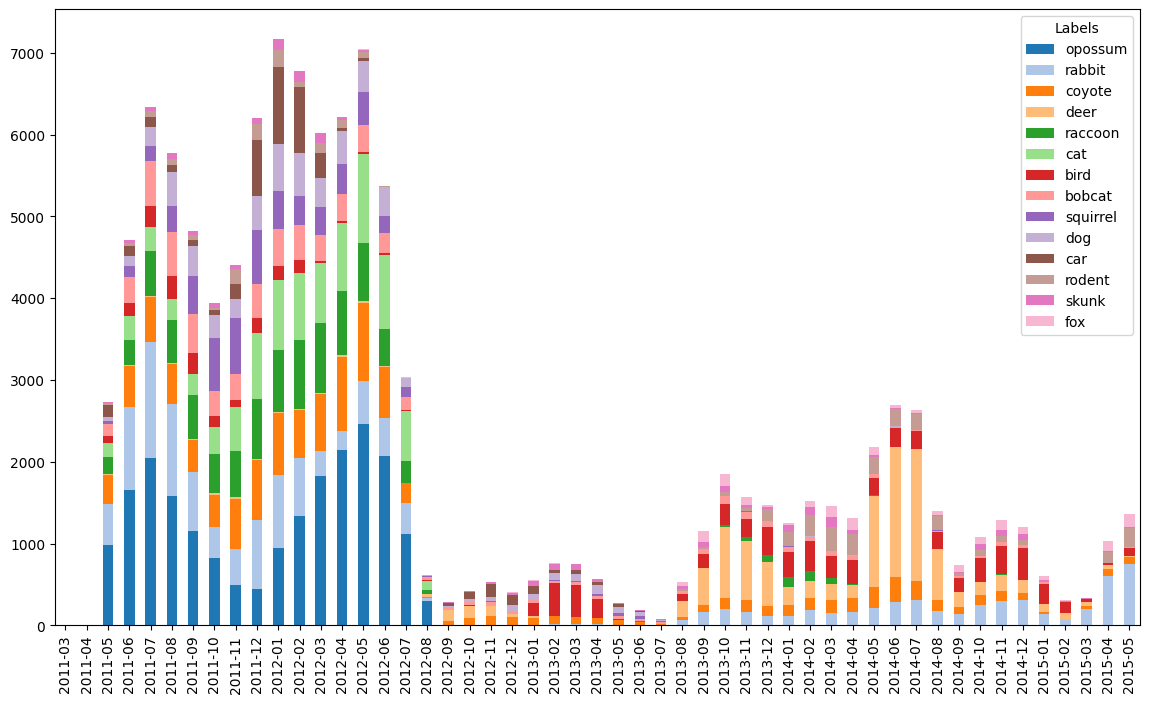

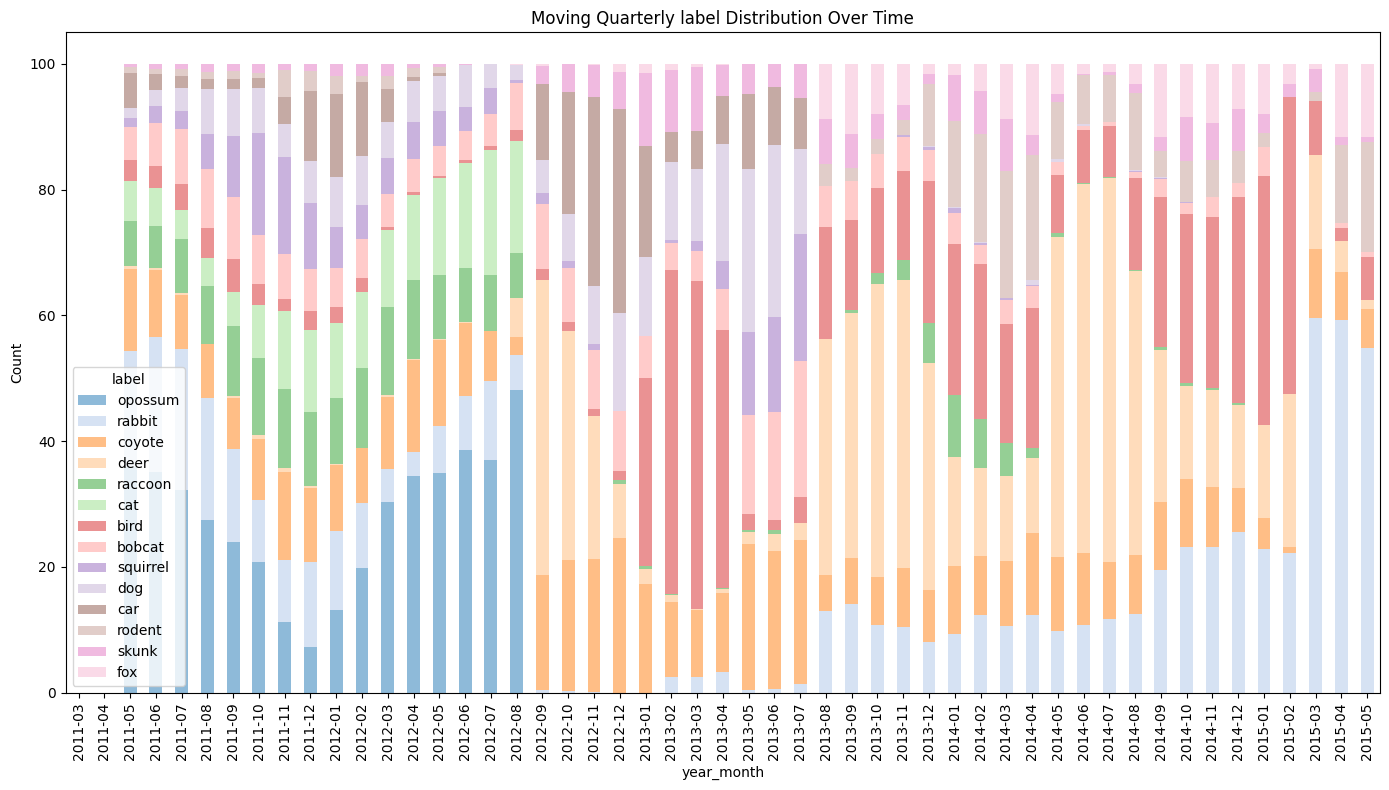

In [17]:
# show moving-quarterly distribution of animal labels (annotated) from CCT20-suggested "train" locations
eda.plot_quarterly_class_distribution(known_locs_df, feature_name = 'label', color_palette='tab20')

/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan/experiments5/../src/eda/eda_utils.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby(['year_month', feature_name]).size().unstack(fill_value=0)


<Figure size 1400x800 with 0 Axes>

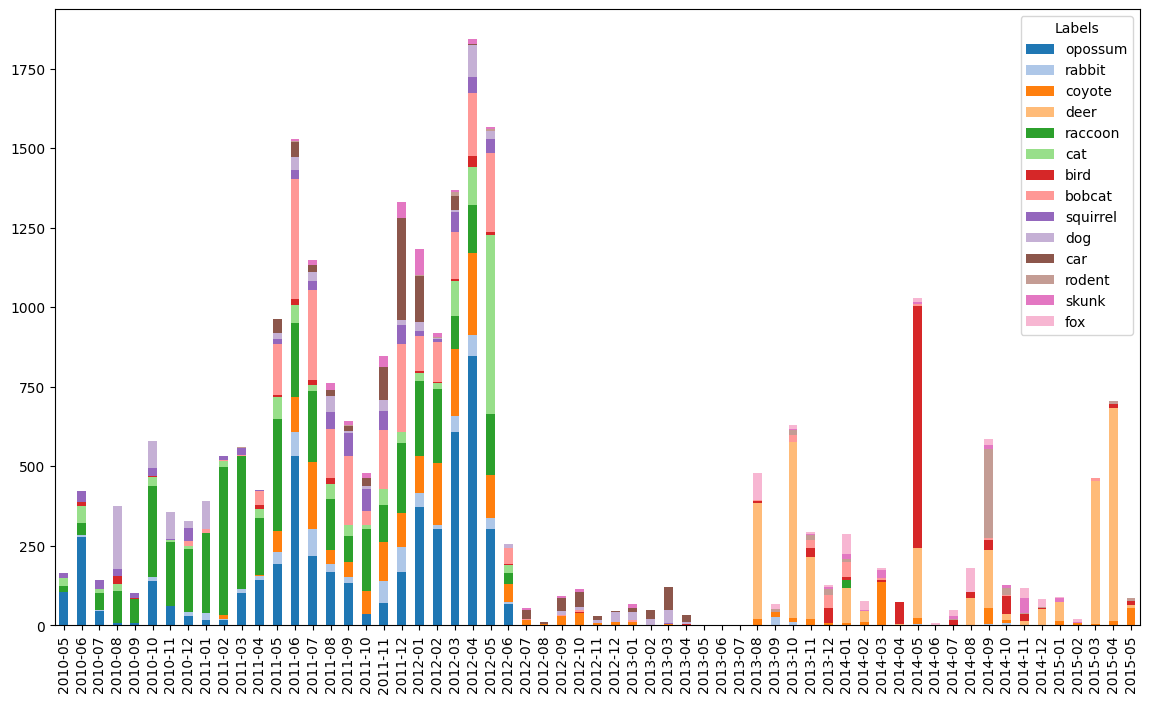

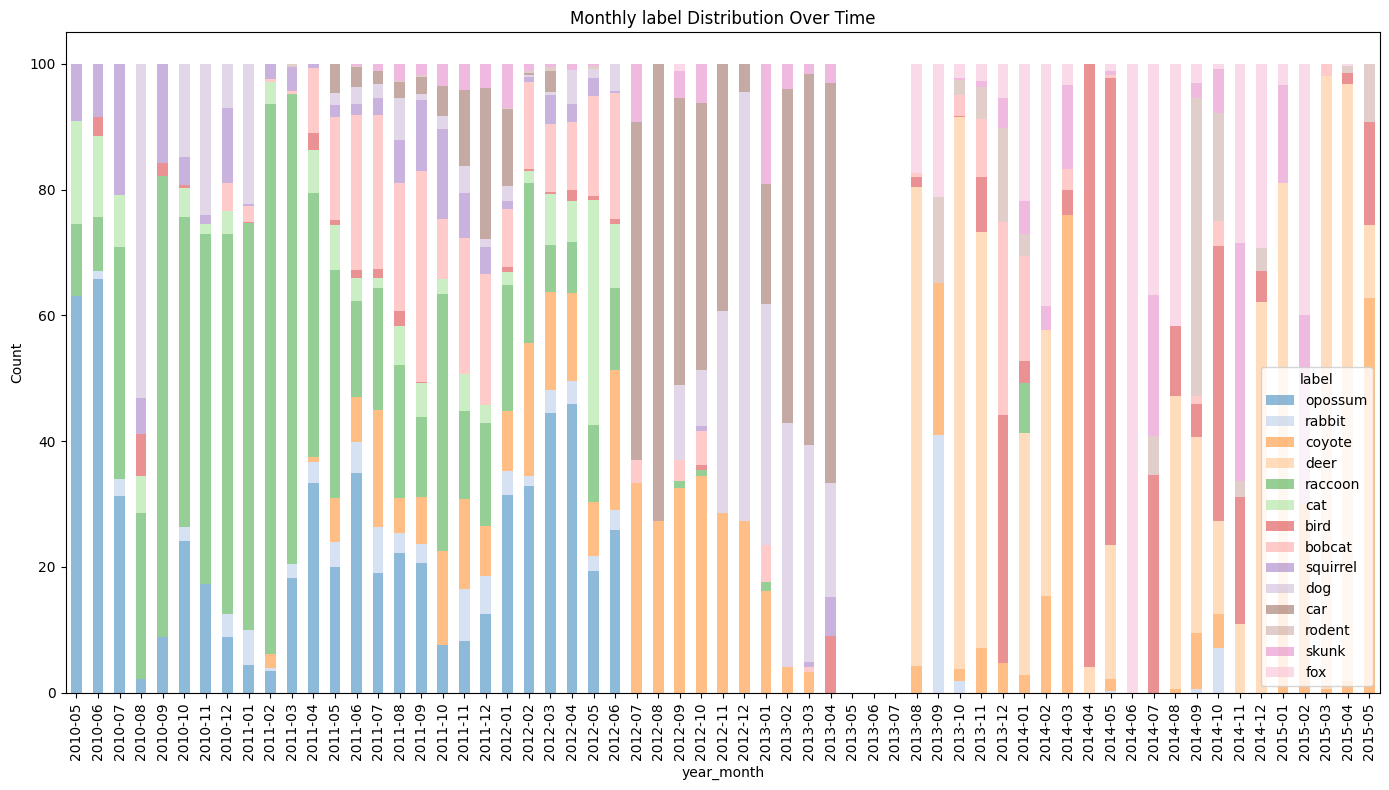

In [18]:
# Check monthly distribution of out of location data
new_locs_df['label'] = pd.Categorical(new_locs_df['label'], categories=known_labels, ordered=True)
eda.plot_monthly_class_distribution(new_locs_df, feature_name = 'label', color_palette='tab20')

/Users/geoffreyfadera/Documents/USD Stuff/AAI-590/Wild-Scan/experiments5/../src/eda/eda_utils.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby(['year_month', feature_name]).size().unstack(fill_value=0)


<Figure size 1400x800 with 0 Axes>

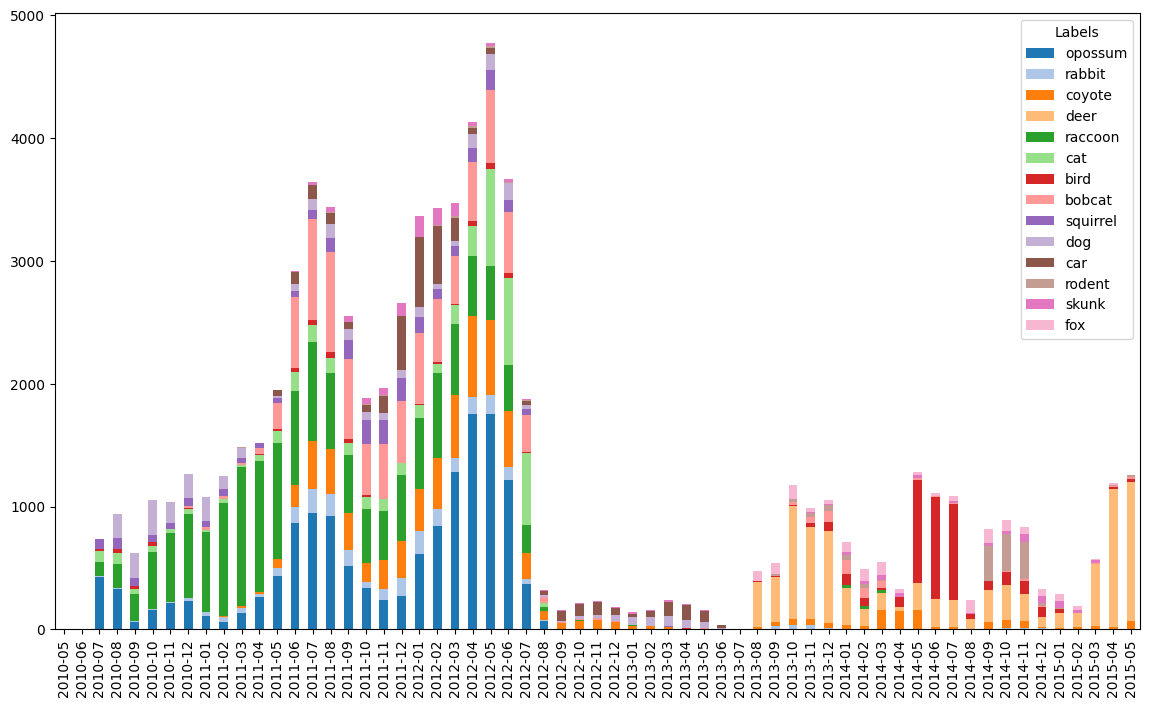

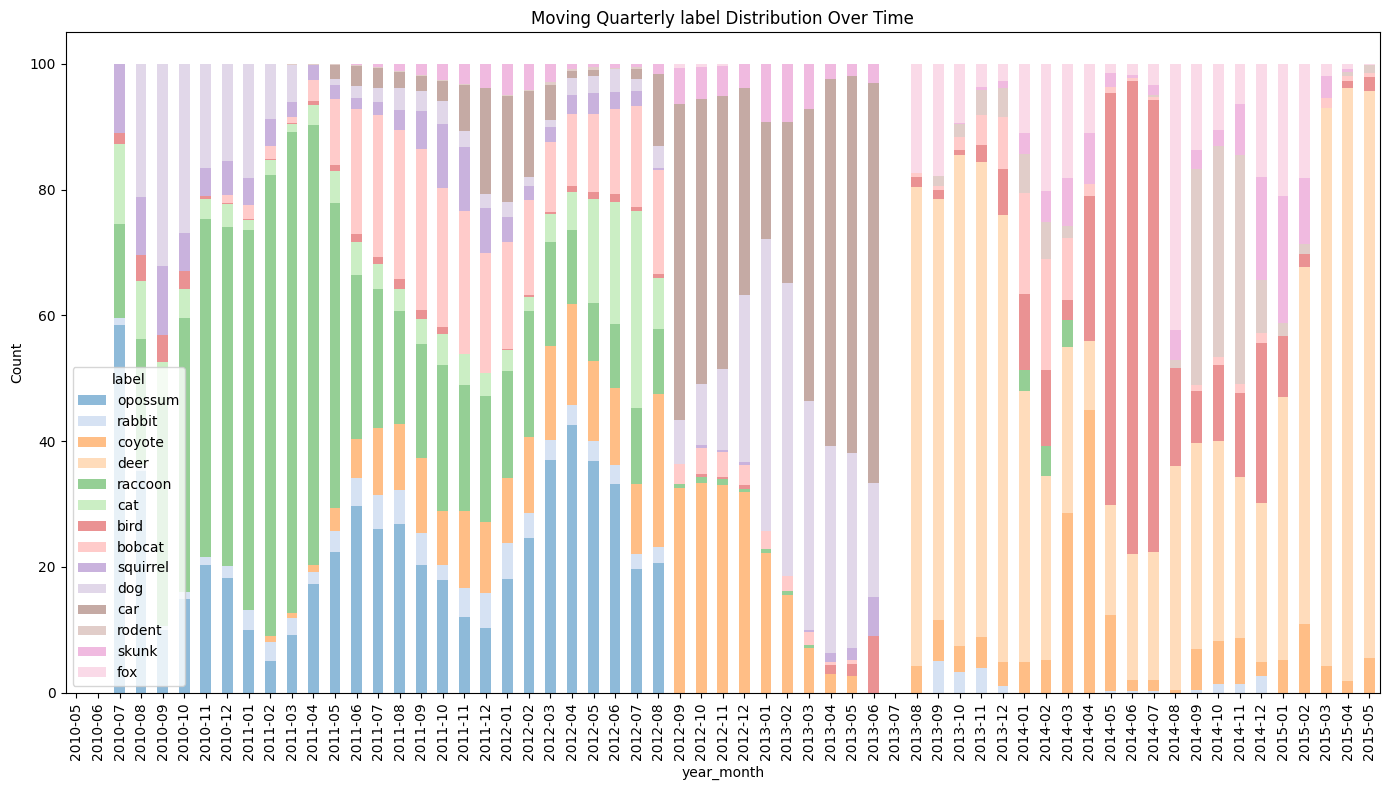

In [19]:
# show moving-quarterly distribution of animal labels (annotated) from CCT20-suggested "train" locations
eda.plot_quarterly_class_distribution(new_locs_df, feature_name = 'label', color_palette='tab20')

In [23]:
# split known locations into 1st year, and rest of the years, the 1st year is from "2011-03" to "2012-02" as seen in the EDA above
# just use between() function
in_loc_df_year1 = known_locs_df[known_locs_df['year_month'].between('2011-03', '2012-02')]
out_loc_df_year1 = new_locs_df[new_locs_df['year_month'].between('2011-03', '2012-02')]

# create production df for rest of the years from '2012-03' 
in_loc_prod_df = known_locs_df[known_locs_df['year_month'].between('2012-03', '2015-05')]
out_loc_prod_df = new_locs_df[new_locs_df['year_month'].between('2012-03', '2015-05')]

# print shapes for each df
print(f'In-location Year 1 shape: {in_loc_df_year1.shape}')
print(f'Out-location Year 1 shape: {out_loc_df_year1.shape}')
print(f'In-location Production shape: {in_loc_prod_df.shape}')
print(f'Out-location Production shape: {out_loc_prod_df.shape}')

In-location Year 1 shape: (19694, 15)
Out-location Year 1 shape: (10788, 15)
In-location Production shape: (19387, 15)
Out-location Production shape: (11401, 15)


/var/folders/9z/w62pgfx92qv9tjyd0820s5h00000gn/T/ipykernel_45287/492879851.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)


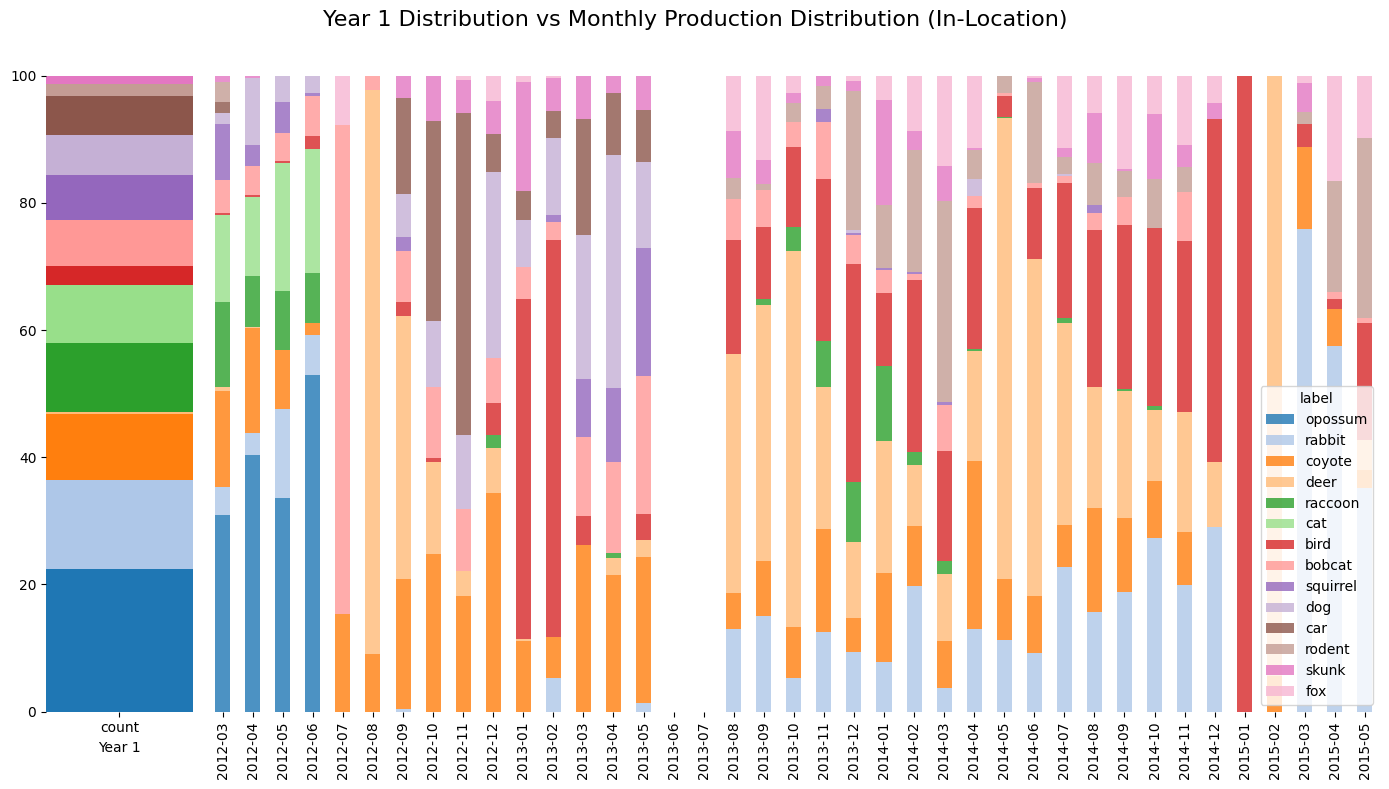

In [106]:
# create a figure with two subplots, gridspec of 1 row and 2 columns, 1st subplot is a stacked bar plot of animal class distributions during the 1st year , the 2nd subplot is the monthly distribution of animal class distributions during the production period
# use gridspec
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.25, 2])
# Plot the stacked bar plot for the first year
sns.set_palette("tab20", n_colors=len(known_labels))
in_loc_year1_counts = in_loc_df_year1['label'].value_counts()
in_loc_year1_counts = in_loc_year1_counts.reindex(known_labels, fill_value=0)

# 1st year stacked % distribution
ax_img = plt.subplot(gs[0])
tmp_value_counts = pd.DataFrame(in_loc_year1_counts.copy())
tmp_df = tmp_value_counts.T.copy()
value_counts_percent = tmp_df.div(tmp_df.sum(axis=1), axis=0) * 100
ax = value_counts_percent.plot(kind='bar', stacked=True, ax=ax_img, legend=False)
ax.set_xlim( -0.2, 0.2)
ax.set_frame_on(False)
ax.set_xlabel('Year 1')
plt.xticks(rotation=0)

# rest of the year production distribution, monthly
ax2_img = plt.subplot(gs[1])
df = in_loc_prod_df.copy()
df['date_captured'] = pd.to_datetime(df['date_captured'], errors='coerce')
df['year_month'] = df['date_captured'].dt.to_period('M')
monthly_counts = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)
all_periods = pd.period_range(start=df['year_month'].min(), end=df['year_month'].max(), freq='M')
monthly_counts = monthly_counts.reindex(all_periods, fill_value=0)
monthly_counts_percentage = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100
    
ax2 = monthly_counts_percentage.plot(kind='bar', stacked=True, figsize=(14, 8), alpha=0.8, ax=ax2_img)
ax2.yaxis.set_visible(False)
ax2.set_frame_on(False)
plt.suptitle('Year 1 Distribution vs Monthly Production Distribution (In-Location)', fontsize=16)
plt.tight_layout()
plt.show()


/var/folders/9z/w62pgfx92qv9tjyd0820s5h00000gn/T/ipykernel_45287/359679659.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)


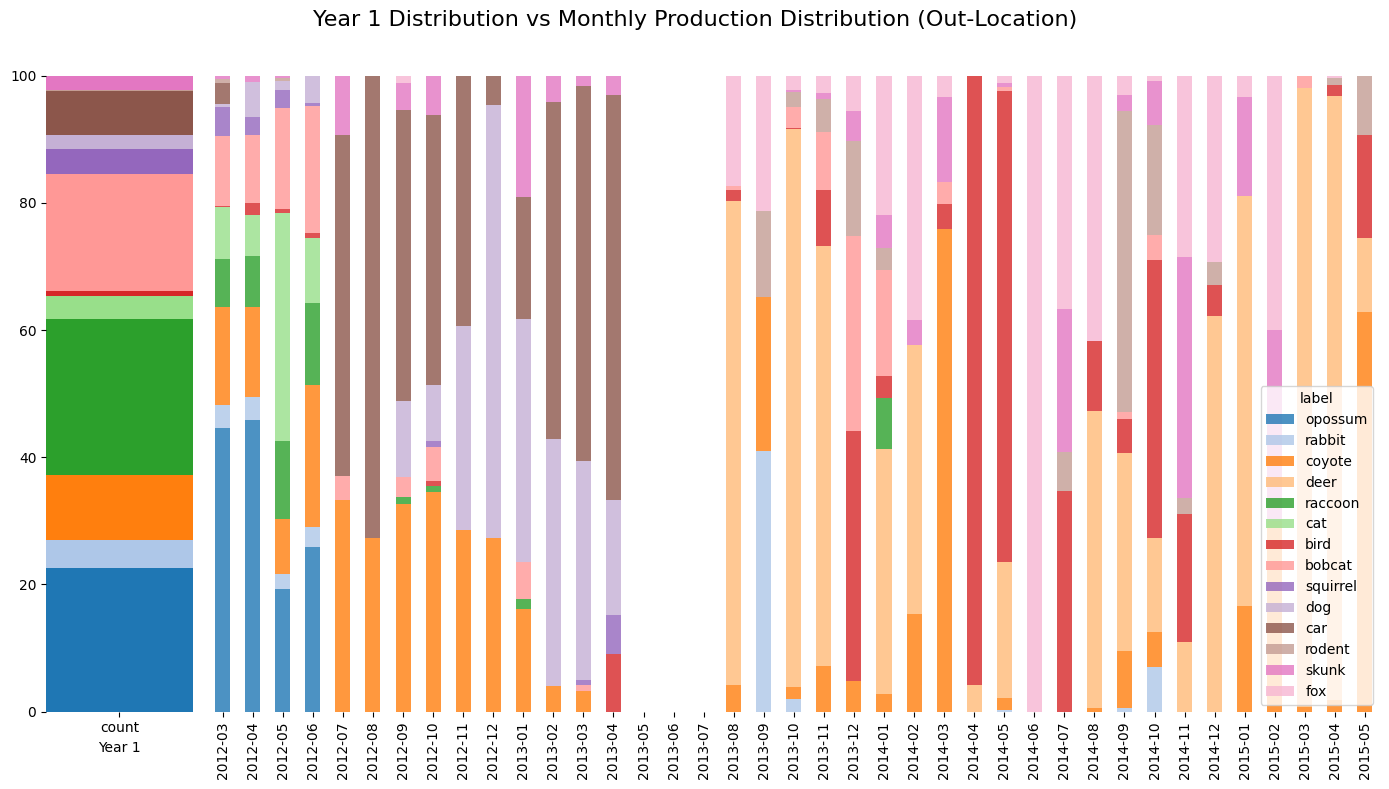

In [107]:
fig = plt.figure(figsize=(8, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[0.25, 2])
# Plot the stacked bar plot for the first year
sns.set_palette("tab20", n_colors=len(known_labels))
out_loc_year1_counts = out_loc_df_year1['label'].value_counts()
out_loc_year1_counts = out_loc_year1_counts.reindex(known_labels, fill_value=0)

# 1st year stacked % distribution
ax_img = plt.subplot(gs[0])
tmp_value_counts = pd.DataFrame(out_loc_year1_counts.copy())
tmp_df = tmp_value_counts.T.copy()
value_counts_percent = tmp_df.div(tmp_df.sum(axis=1), axis=0) * 100
ax = value_counts_percent.plot(kind='bar', stacked=True, ax=ax_img, legend=False)
ax.set_xlim( -0.2, 0.2)
ax.set_frame_on(False)
ax.set_xlabel('Year 1')
plt.xticks(rotation=0)

# rest of the year production distribution, monthly
ax2_img = plt.subplot(gs[1])
df = out_loc_prod_df.copy()
df['date_captured'] = pd.to_datetime(df['date_captured'], errors='coerce')
df['year_month'] = df['date_captured'].dt.to_period('M')
monthly_counts = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)
all_periods = pd.period_range(start=df['year_month'].min(), end=df['year_month'].max(), freq='M')
monthly_counts = monthly_counts.reindex(all_periods, fill_value=0)
monthly_counts_percentage = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100
    
ax2 = monthly_counts_percentage.plot(kind='bar', stacked=True, figsize=(14, 8), alpha=0.8, ax=ax2_img)
ax2.yaxis.set_visible(False)
ax2.set_frame_on(False)
plt.suptitle('Year 1 Distribution vs Monthly Production Distribution (Out-Location)', fontsize=16)
plt.tight_layout()
plt.show()

---
### Observations

        * obvious temporal shift in class distributions for both in-loc and out-loc data
        * while the in-loc and out-loc distributions are somewhat comparable for the entire year 1, the monthly distribution plots of the production data reveal otherwise.. 
        * this split allows us to simulate the deployment of our ML system on both new locations (spatial) and on new data from the same locations (temporal) in presence of distribution shifts